# **Stroke Risk Analysis Report Group 2 - CIS9660**
Sophia Gloade, Christine Alexander,Tanvir Limon,Albina Osipina


In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 03/18/26 00:46:49


# Import Libraries

In [2]:
#Importing the models needed for our analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import seaborn as sns



# Data Examination

In [3]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1mMbTJ__af2y_558JNruwtC25uMAioJ1j",index_col = "id")

In [4]:
df.shape

(5110, 11)

In [5]:
df.head () #overview of data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.describe() #data statistics

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
# Nulls

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


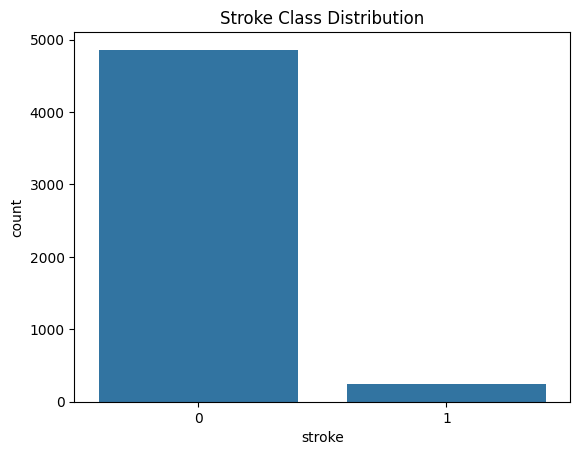

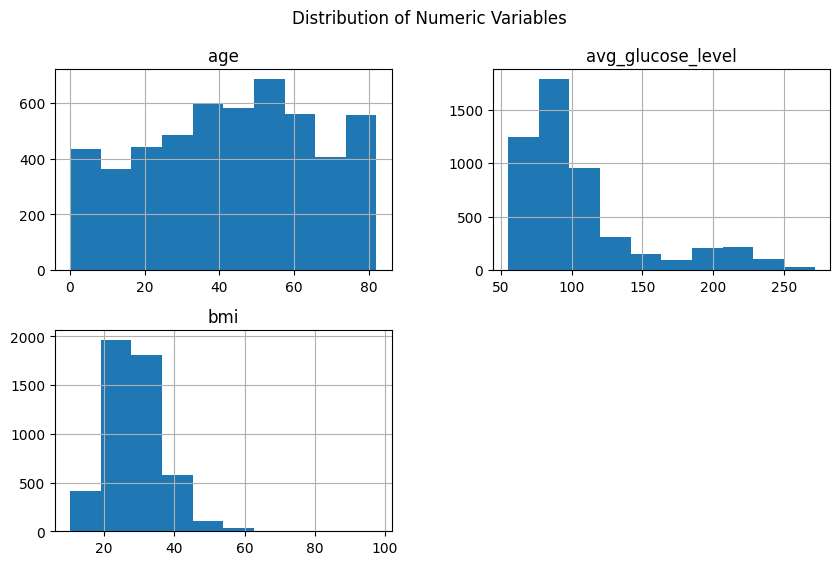

In [8]:
# Check Target balance

sns.countplot(x='stroke', data=df)
plt.title('Stroke Class Distribution')
plt.show()

# Plot Histograms for meaningful variables

df[['age', 'avg_glucose_level', 'bmi']].hist(figsize=(10,6))
plt.suptitle('Distribution of Numeric Variables')
plt.show()



# Data Preparation

In [9]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

In [10]:
#Converting categorical data to numeric values

X = pd.get_dummies(X, drop_first=True)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
id,,,,,,,,,,,,,,,,
9046,67.0,0,1,228.69,36.6,1,0,1,0,1,0,0,1,1,0,0
51676,61.0,0,0,202.21,NaN,0,0,1,0,0,1,0,0,0,1,0
31112,80.0,0,1,105.92,32.5,1,0,1,0,1,0,0,0,0,1,0
60182,49.0,0,0,171.23,34.4,0,0,1,0,1,0,0,1,0,0,1
1665,79.0,1,0,174.12,24.0,0,0,1,0,0,1,0,0,0,1,0


# Split Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# Input median for missing BMIs

imputer = SimpleImputer(strategy="median")
X_train["bmi"] = imputer.fit_transform(X_train[["bmi"]]).ravel()
X_test["bmi"] = imputer.transform(X_test[["bmi"]]).ravel()

In [13]:
# Verify that all missing values were handled in training and test data sets

print(X_train.isnull().sum())
print(X_test.isnull().sum())

age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_child

In [14]:
# Scale the data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #adding test scaler

In [15]:
# Check the scaled data

print(X_train[:3])
print(X_test[:3])

        age  hypertension  heart_disease  avg_glucose_level   bmi  \
id                                                                  
25283  48.0             0              0              69.21  33.1   
43734  15.0             0              0             122.25  21.0   
47113  67.0             0              0             110.42  24.9   

       gender_Male  gender_Other  ever_married_Yes  work_type_Never_worked  \
id                                                                           
25283            0             0                 1                       0   
43734            1             0                 0                       0   
47113            0             0                 1                       0   

       work_type_Private  work_type_Self-employed  work_type_children  \
id                                                                      
25283                  1                        0                   0   
43734                  1                    

# **KNN Train Model**

In [16]:
# KNN and baseline parameters

knn = KNeighborsClassifier()
print(knn.get_params())

# Train KNN and Generate predictions

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [17]:
# Print classification report for KNN
print("KNN Classification Report")
print(classification_report(y_test, y_pred_knn))

# Print confusion matrix for KNN
print("KNN Confusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

KNN Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.20      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.58      0.51      0.50      1022
weighted avg       0.92      0.95      0.93      1022

KNN Confusion Matrix
[[968   4]
 [ 49   1]]


In [18]:
# KNN Baseline Accuracy

print("Training Accuracy:", round(knn.score(X_train_scaled, y_train)*100,2),"%")

Training Accuracy: 95.23 %


In [19]:
print("Test Accuracy:", round(knn.score(X_test_scaled, y_test)*100,2), "%")

Test Accuracy: 94.81 %


Retraining the KNN model

In [20]:
# Retrain KNN with Distance based weight

knn2 = KNeighborsClassifier(n_neighbors=7, weights='distance')
print(knn2.get_params())

knn2.fit(X_train_scaled, y_train)
y_pred_knn2 = knn2.predict(X_test_scaled)

print("Tuned KNN Classification Report")
print(classification_report(y_test, y_pred_knn2))

print("Tuned KNN Confusion Matrix")
print(confusion_matrix(y_test, y_pred_knn2))

print("Training Accuracy:", knn2.score(X_train_scaled, y_train) * 100, "%")
print("Test Accuracy:", knn2.score(X_test_scaled, y_test) * 100, "%")

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 7, 'p': 2, 'weights': 'distance'}
Tuned KNN Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Tuned KNN Confusion Matrix
[[968   4]
 [ 50   0]]
Training Accuracy: 100.0 %
Test Accuracy: 94.71624266144813 %


In [21]:
# Train another KNN with more neighbors and uniform weighting

knn3 = KNeighborsClassifier(n_neighbors=15, weights='uniform')
print(knn3.get_params())

knn3.fit(X_train_scaled, y_train)
y_pred_knn3 = knn3.predict(X_test_scaled)

print("Tuned KNN 2 Classification Report")
print(classification_report(y_test, y_pred_knn3))

print("Tuned KNN 2 Confusion Matrix")
print(confusion_matrix(y_test, y_pred_knn3))

print("Training Accuracy:", round(knn3.score(X_train_scaled, y_train) * 100,2), "%")
print("Test Accuracy:", round(knn3.score(X_test_scaled, y_test) * 100,2), "%")

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
Tuned KNN 2 Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Tuned KNN 2 Confusion Matrix
[[971   1]
 [ 50   0]]
Training Accuracy: 95.13 %
Test Accuracy: 95.01 %


# **Logistic Regression Train Model**

In [22]:
# Train logistic regression with balanced class weights
# to improve detection of stroke

model = LogisticRegression(
    max_iter=10000,
    class_weight='balanced',
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000)

In [23]:
print("Training Accuracy:", round(model.score(X_train_scaled, y_train)*100,2),"%")

Training Accuracy: 74.0 %


In [24]:
print("Test Accuracy:", round((model.score(X_test_scaled, y_test) * 100), 2), "%")

Test Accuracy: 74.66 %


In [25]:
# Evaluate performance; recall is important due to rare stroke cases
log_reg = model
print(log_reg.get_params())

log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print("\nBaseline Logistic Regression Classification Report")
target_names = ['no stoke', 'had stroke']
print(classification_report(y_test, y_pred_log,target_names = target_names))

print("Baseline Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("Training Accuracy:", round(model.score(X_train_scaled, y_train)*100,2),"%")
print("Test Accuracy:", round((model.score(X_test_scaled, y_test) * 100), 2), "%")

{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 10000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Baseline Logistic Regression Classification Report
              precision    recall  f1-score   support

    no stoke       0.99      0.74      0.85       972
  had stroke       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022

Baseline Logistic Regression Confusion Matrix
[[723 249]
 [ 10  40]]
Training Accuracy: 74.0 %
Test Accuracy: 74.66 %


In [26]:
# Ai Assitance to make a table to show how each predictor affects the chances of having a stroke.
# Positive = increase chances of stoke based on variable, while negative = decreased chances of stoke based on variable.

table = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": model.coef_[0]
})
table.sort_values(by="Coefficient", ascending=False)

,Variable,Coefficient
0,age,1.885512
11,work_type_children,0.349906
3,avg_glucose_level,0.199247
1,hypertension,0.176801
15,smoking_status_smokes,0.119808
12,Residence_type_Urban,0.075394
13,smoking_status_formerly smoked,0.058014
2,heart_disease,0.052306
4,bmi,0.051340
9,work_type_Private,0.012105


Retraining Logistic Regression

In [27]:
# Apply stronger regularization than the default setting

model1 = LogisticRegression(
    max_iter=10000, class_weight = 'balanced', C=0.1
)
model1.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=10000)

In [28]:
print("Training Accuracy:", round(model1.score(X_train_scaled, y_train)*100,2),"%")

Training Accuracy: 73.78 %


In [29]:
print("Test Accuracy:", round((model1.score(X_test_scaled, y_test) * 100), 2), "%")

Test Accuracy: 74.56 %


In [30]:
# Apply stronger regularization than the default setting

log_reg1 = model1
log_reg1.fit(X_train_scaled, y_train)
y_pred_log_none = log_reg1.predict(X_test_scaled)

print(log_reg1.get_params())

print("\nTuned Logistic Regression Classification Report:")
target_names = ['no stoke', 'had stroke']
print(classification_report(y_test, y_pred_log_none,target_names = target_names))

print("Tuned Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_none))

print("Training Accuracy:", round(model1.score(X_train_scaled, y_train)*100,2),"%")
print("Test Accuracy:", round((model1.score(X_test_scaled, y_test) * 100), 2), "%")

{'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 10000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

    no stoke       0.99      0.74      0.85       972
  had stroke       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022

Tuned Logistic Regression Confusion Matrix:
[[722 250]
 [ 10  40]]
Training Accuracy: 73.78 %
Test Accuracy: 74.56 %


# **Random Forest Train Model**

In [31]:
# Baseline Random Forest Model
rf= RandomForestClassifier(random_state= 42)

In [32]:
print('RandomForestClassifier default hyperparameters\n')
rf.get_params()

RandomForestClassifier default hyperparameters



{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [33]:
# Train the Random Forest Model

%%time
rf.fit(X_train_scaled, y_train)

CPU times: user 856 ms, sys: 6.4 ms, total: 863 ms
Wall time: 1.81 s


RandomForestClassifier(random_state=42)

In [34]:
y_pred= rf.predict(X_test_scaled)

In [35]:
# Overall Accuracy

accuracy_score1= accuracy_score(y_test, y_pred)
print(f'Accuracy= {round((accuracy_score1*100), 2)}%')

Accuracy= 94.72%


In [36]:
# Print classification metrics to evaluate model performance

target_names1 = ['no stoke', 'had stroke']
print("Classification Report:\n")
print(classification_report(y_test, y_pred,target_names= target_names1))

Classification Report:

              precision    recall  f1-score   support

    no stoke       0.95      1.00      0.97       972
  had stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



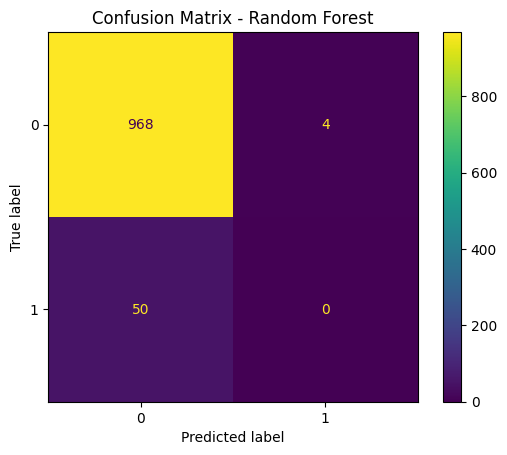

In [37]:
# Create and display the confusion matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

Retraining the Random forest

In [38]:
# Retrain Random Forest with more trees and balanced class weights

rf1 = RandomForestClassifier(n_estimators=1000, class_weight='balanced', random_state=42)

In [39]:
# Measure training time for the tuned Random Forest model

%%time

rf1.fit(X_train_scaled, y_train)

CPU times: user 8.11 s, sys: 105 ms, total: 8.22 s
Wall time: 14.2 s


RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=42)

In [40]:
# Generate predictions with the tuned model

y_pred1= rf1.predict(X_test_scaled)

In [41]:
accuracy_score2= accuracy_score(y_test, y_pred1)
print(f'Accuracy= {round((accuracy_score2*100), 2)}%')

Accuracy= 95.01%


In [42]:
# Print classification metrics for the tuned model

target_names2 = ['no stoke', 'had stroke']
print("Classification Report:\n")
print(classification_report(y_test, y_pred1,target_names = target_names2))

Classification Report:

              precision    recall  f1-score   support

    no stoke       0.95      1.00      0.97       972
  had stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



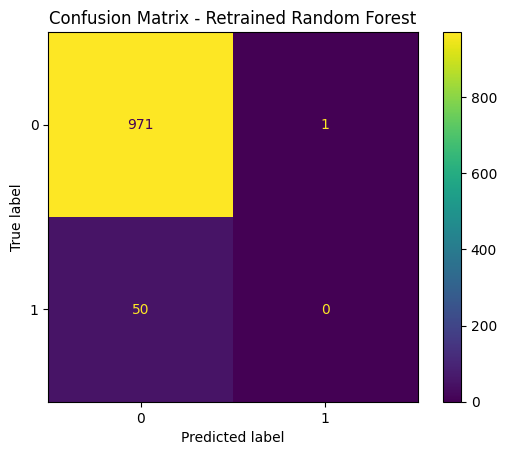

In [43]:
# Plot confusion matrix for the tuned Random Forest model

cm1 = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp.plot()
plt.title("Confusion Matrix - Retrained Random Forest")
plt.show()

**Support Vector Classifier (SVC) Model**

In [44]:
# Train Baseline SVC

svc_base = SVC(probability=True)
print(svc_base.get_params())
svc_base.fit(X_train_scaled, y_train)

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


SVC(probability=True)

In [45]:
# Generate predictions

y_pred_svc_base = svc_base.predict(X_test_scaled)

In [46]:
accuracy = accuracy_score(y_test, y_pred_svc_base)
print(f'Accuracy: {round(accuracy * 100, 2)}%')

Accuracy: 95.11%


In [47]:
# Print classification metrics for the baseline SVC model

target_names = ['no stroke', 'had stroke']
print("Baseline SVC Classification Report")
print(classification_report(y_test, y_pred_svc_base, target_names=target_names, zero_division=0))

Baseline SVC Classification Report
              precision    recall  f1-score   support

   no stroke       0.95      1.00      0.97       972
  had stroke       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



In [48]:
print("Baseline SVC Confusion Matrix")
print(confusion_matrix(y_test, y_pred_svc_base))

Baseline SVC Confusion Matrix
[[972   0]
 [ 50   0]]


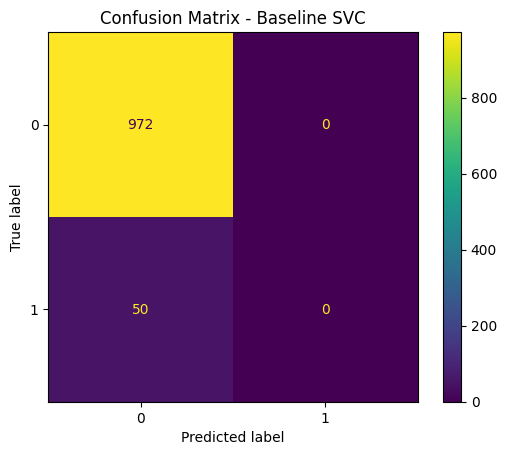

In [49]:
# Plot confusion matrix for the baseline SVC model

cm = confusion_matrix(y_test, y_pred_svc_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Baseline SVC")
plt.show()

Retraining the SVC Model

In [50]:
# Train tuned SVC model with balanced class weights

svc_model = SVC(class_weight='balanced', probability=True, random_state=42)
print(svc_model.get_params())
svc_model.fit(X_train_scaled, y_train)


{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': 'balanced', 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


SVC(class_weight='balanced', probability=True, random_state=42)

In [51]:
# Generate predictions using the tuned SVC model

y_pred_svc = svc_model.predict(X_test_scaled)

In [52]:
# Print classification metrics for the tuned SVC model
target_names = ['no stoke', 'had stroke']
print("SVC Classification Report")
print(classification_report(y_test, y_pred_svc, target_names=target_names))

SVC Classification Report
              precision    recall  f1-score   support

    no stoke       0.98      0.78      0.87       972
  had stroke       0.14      0.68      0.23        50

    accuracy                           0.77      1022
   macro avg       0.56      0.73      0.55      1022
weighted avg       0.94      0.77      0.84      1022



In [53]:
accuracy = accuracy_score(y_test, y_pred_svc)
print(f'accuracy= {round((accuracy*100), 2)}%')

accuracy= 77.4%


In [54]:
# Print confusion matrix values for the tuned SVC model

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_svc))

Confusion Matrix
[[757 215]
 [ 16  34]]


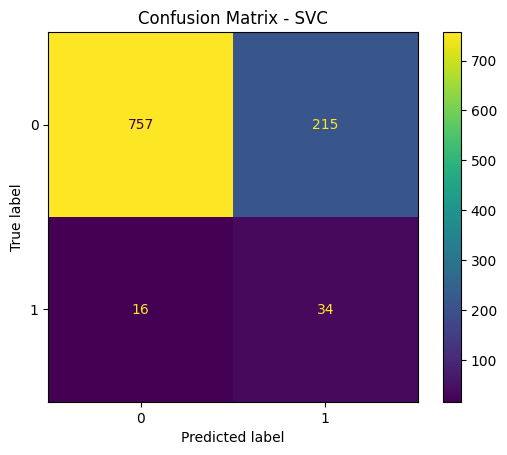

In [55]:
# Plot confusion matrix for the tuned SVC model

cm = confusion_matrix(y_test, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVC")
plt.show()

Comparison

In [56]:
# Baseline Summary

baseline_results = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'Random Forest', 'SVC'],
    'Accuracy': [0.95, 0.95, 0.9472, 0.9511],
    'Precision': [0.20, 1.00, 0.00, 0.00],
    'Recall': [0.02, 0.02, 0.00, 0.00]
})

baseline_results

,Model,Accuracy,Precision,Recall
0,KNN,0.9500,0.2,0.02
1,Logistic Regression,0.9500,1.0,0.02
2,Random Forest,0.9472,0.0,0.00
3,SVC,0.9511,0.0,0.00


In [57]:
# Tuned Summary

tuned_results = pd.DataFrame({
    'Model': ['KNN', 'Logistic Regression', 'Random Forest', 'SVC'],
    'Accuracy': [0.95, 0.7466, 0.9501, 0.7740],
    'Precision': [0.00, 0.14, 0.00, 0.14],
    'Recall': [0.00, 0.80, 0.00, 0.68]
})

tuned_results

,Model,Accuracy,Precision,Recall
0,KNN,0.9500,0.00,0.00
1,Logistic Regression,0.7466,0.14,0.80
2,Random Forest,0.9501,0.00,0.00
3,SVC,0.7740,0.14,0.68


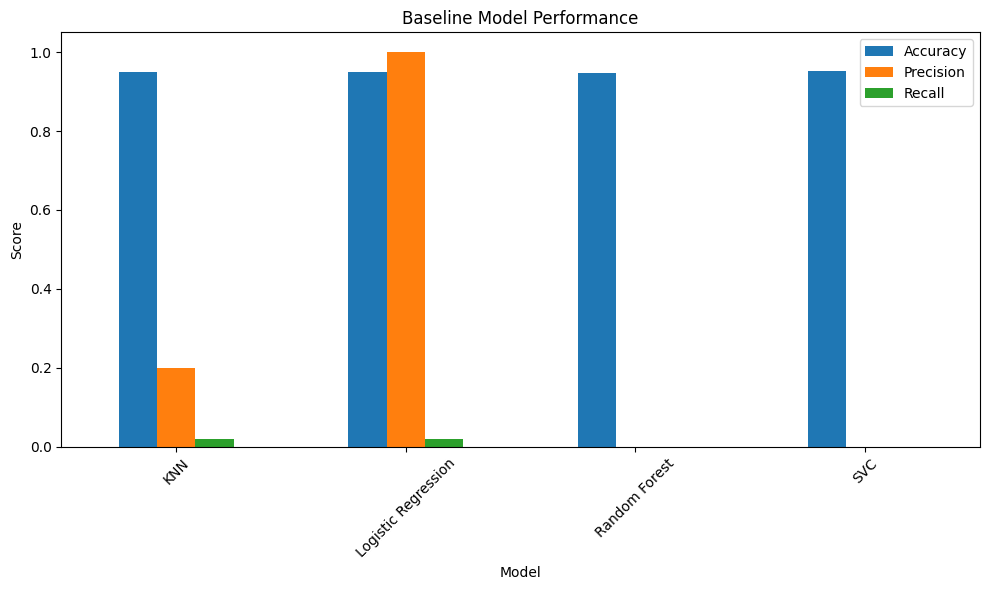

In [58]:
# Baseline Bar Chart

baseline_plot = baseline_results.set_index('Model')

baseline_plot.plot(kind='bar', figsize=(10,6))
plt.title('Baseline Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

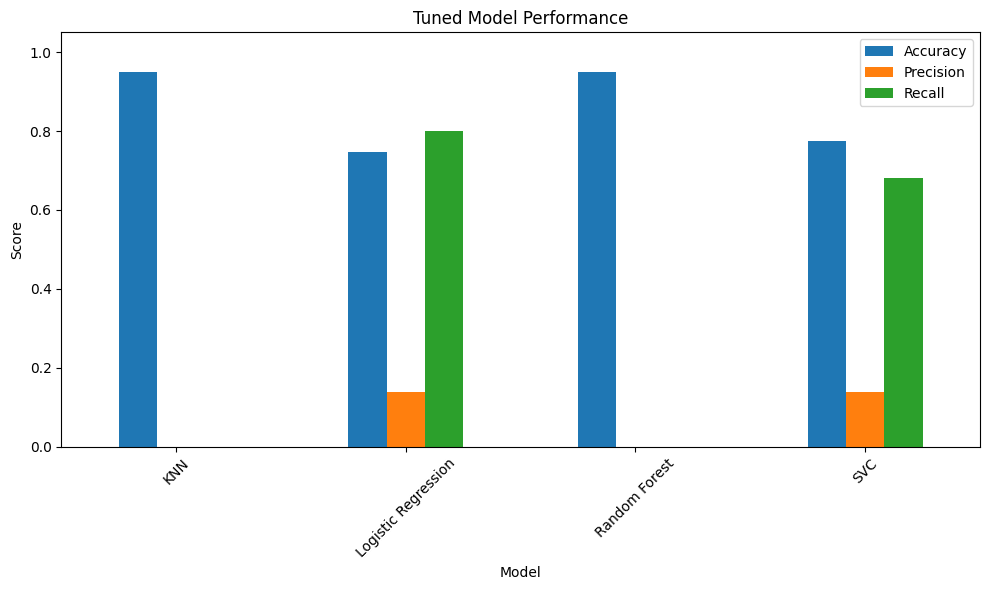

In [59]:
# Tuned Bar Chart

tuned_plot = tuned_results.set_index('Model')

tuned_plot.plot(kind='bar', figsize=(10,6))
plt.title('Tuned Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
print("Final Conclusion:")
print("Among the baseline models, most classifiers achieved high accuracy but failed to detect stroke cases well because of class imbalance.")
print("After tuning, Logistic Regression and SVC improved recall for the stroke class substantially.")
print("The tuned Logistic Regression model performed best overall because it achieved the highest recall for stroke cases while maintaining reasonable overall performance.")
print("Therefore, tuned Logistic Regression was selected as the final model for stroke prediction.")

Final Conclusion:
Among the baseline models, most classifiers achieved high accuracy but failed to detect stroke cases well because of class imbalance.
After tuning, Logistic Regression and SVC improved recall for the stroke class substantially.
The tuned Logistic Regression model performed best overall because it achieved the highest recall for stroke cases while maintaining reasonable overall performance.
Therefore, tuned Logistic Regression was selected as the final model for stroke prediction.
